# HR Workforce Analytics

## Objective
Analyze employee attrition to identify key drivers of turnover and provide actionable insights for HR leadership.

## Key Questions
- Which employees are most likely to leave?
- What factors drive attrition?
- How can HR improve retention?

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

df = pd.read_csv("../data/clean_hr_data.csv")
df.head()

,age,attrition,businesstravel,dailyrate,department,distancefromhome,education,educationfield,employeecount,employeenumber,...,stockoptionlevel,totalworkingyears,trainingtimeslastyear,worklifebalance,yearsatcompany,yearsincurrentrole,yearssincelastpromotion,yearswithcurrmanager,attrition_flag,tenure_group
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,0,8,0,1,6,4,0,5,1,6-10
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,1,10,3,3,10,7,1,7,0,6-10
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,0,7,3,3,0,0,0,0,1,NaN
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,0,8,3,3,8,7,3,0,0,6-10
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,1,6,3,3,2,2,2,2,0,0-2


In [16]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   age                       1470 non-null   int64
 1   attrition                 1470 non-null   str  
 2   businesstravel            1470 non-null   str  
 3   dailyrate                 1470 non-null   int64
 4   department                1470 non-null   str  
 5   distancefromhome          1470 non-null   int64
 6   education                 1470 non-null   int64
 7   educationfield            1470 non-null   str  
 8   employeecount             1470 non-null   int64
 9   employeenumber            1470 non-null   int64
 10  environmentsatisfaction   1470 non-null   int64
 11  gender                    1470 non-null   str  
 12  hourlyrate                1470 non-null   int64
 13  jobinvolvement            1470 non-null   int64
 14  joblevel                  1470 non-null   int64
 15

,age,dailyrate,distancefromhome,education,employeecount,employeenumber,environmentsatisfaction,hourlyrate,jobinvolvement,joblevel,...,standardhours,stockoptionlevel,totalworkingyears,trainingtimeslastyear,worklifebalance,yearsatcompany,yearsincurrentrole,yearssincelastpromotion,yearswithcurrmanager,attrition_flag
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129,0.161224
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136,0.367863
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,0.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,0.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000,0.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,1.000000


### Observations
- Dataset contains employee demographics, compensation, and performance metrics
- Attrition is a binary variable (Yes/No → 1/0)

In [17]:
attrition_rate = df["attrition_flag"].mean() * 100
print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


### Insight
Overall attrition rate provides a baseline for workforce stability.

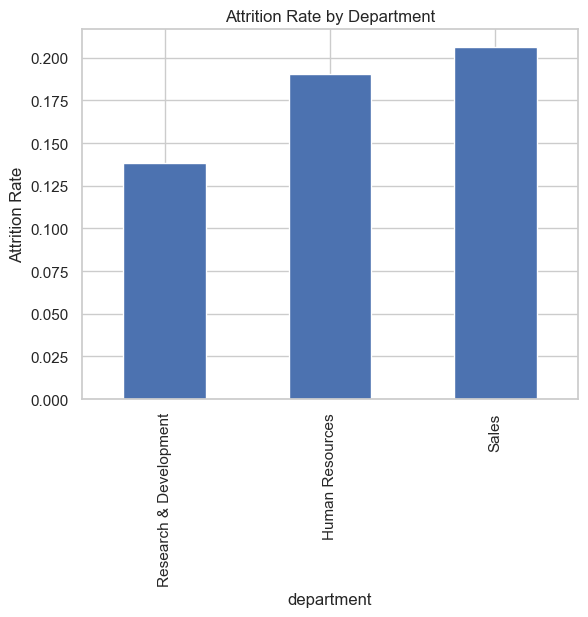

In [18]:
dept_attrition = df.groupby("department")["attrition_flag"].mean().sort_values()

dept_attrition.plot(kind="bar")
plt.title("Attrition Rate by Department")
plt.ylabel("Attrition Rate")
plt.show()

### Insight
Certain departments show significantly higher attrition, indicating potential structural or managerial issues.

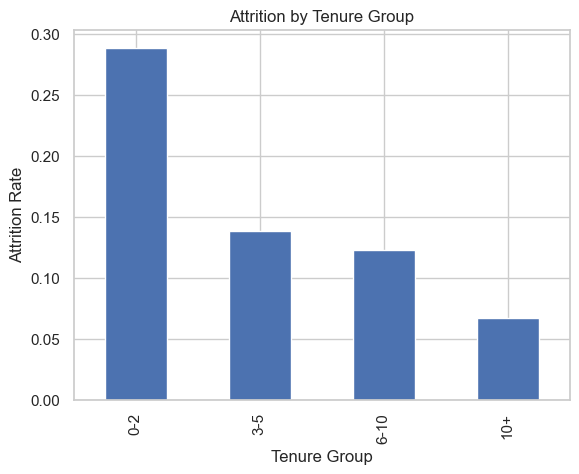

In [22]:
# Define correct order
order = ["0-2", "3-5", "6-10", "10+"]

# Convert to ordered categorical
df["tenure_group"] = pd.Categorical(
    df["tenure_group"],
    categories=order,
    ordered=True
)

tenure_attrition = df.groupby("tenure_group")["attrition_flag"].mean()

tenure_attrition.plot(kind="bar")
plt.title("Attrition by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Attrition Rate")
plt.show()

### Key Insight
Employees with lower tenure show higher attrition, suggesting onboarding or early engagement issues.

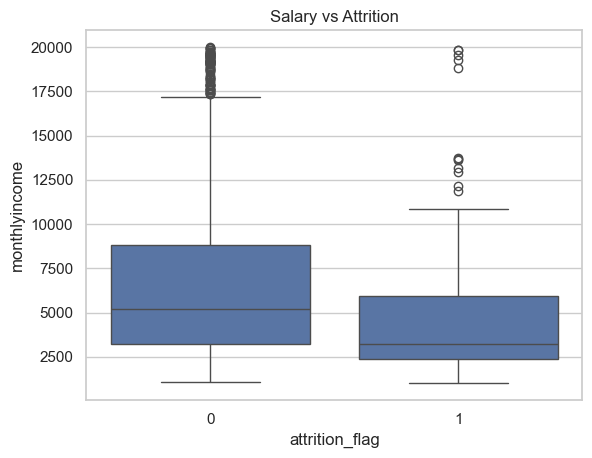

In [23]:
sns.boxplot(x="attrition_flag", y="monthlyincome", data=df)
plt.title("Salary vs Attrition")
plt.show()

### Insight
Lower compensation bands may correlate with higher attrition risk.

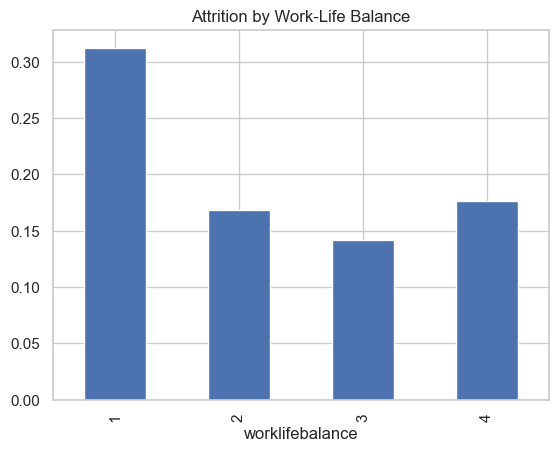

In [24]:
wlb = df.groupby("worklifebalance")["attrition_flag"].mean()

wlb.plot(kind="bar")
plt.title("Attrition by Work-Life Balance")
plt.show()

### Key Insight
Employees with lower work-life balance scores are more likely to leave.

# Executive Insights

## Key Findings

- Employees with <2 years tenure have the highest attrition rates
- Work-life balance is a strong predictor of retention
- Certain departments show elevated turnover risk

## Recommendations

- Improve onboarding and early employee engagement
- Address work-life balance through policy changes
- Investigate high-attrition departments for root causes